In [1]:

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [2]:
df = pd.read_csv(r"C:\Users\salma\Downloads\Source_2_Fixtures_2026_Chicago_Stars_All_Competitions.csv")
df.head()

,Date,Time,Comp,Round,Day,Venue,Result,GF,GA,Opponent,Poss,Attendance,Captain,Formation,Opp Formation,Referee,Match Report,Notes
0,2026-03-15,16:00 (01:00),NWSL,Regular Season,Sun,Away,L,0.0,4.0,Angel City FC,40.0,16813.0,Alyssa Naeher,4-2-3-1,4-3-1-2,Shawn Tehini,Match Report,NaN
1,2026-03-22,13:00 (20:00),NWSL,Regular Season,Sun,Away,W,2.0,1.0,Current,50.0,4192.0,Alyssa Naeher,4-2-3-1,4-3-3,Alex Billeter,Match Report,NaN
2,2026-03-25,19:00 (02:00),NWSL,Regular Season,Wed,Home,L,2.0,3.0,Orlando Pride,52.0,1821.0,Alyssa Naeher,4-2-3-1,4-2-3-1,Matthew Thompson,Match Report,NaN
3,2026-03-28,17:45 (02:45),NWSL,Regular Season,Sat,Away,L,0.0,2.0,SD Wave,41.0,12810.0,Alyssa Naeher,4-2-3-1,4-2-3-1,Servando Berna Rico,Match Report,NaN
4,2026-04-03,19:00 (03:00),NWSL,Regular Season,Fri,Away,L,0.0,1.0,Royals,39.0,10012.0,Kathrin Hendrich,4-2-3-1,4-2-3-1,Trevor Wiseman,Match Report,NaN


In [3]:
df.dtypes

Date                 str
Time                 str
Comp                 str
Round                str
Day                  str
Venue                str
Result               str
GF               float64
GA               float64
Opponent             str
Poss             float64
Attendance       float64
Captain              str
Formation            str
Opp Formation        str
Referee              str
Match Report         str
Notes            float64
dtype: object

In [4]:

# Convert Date to datetime format
df["Date"] = pd.to_datetime(df["Date"])

# Convert numeric columns
float_cols = ["GF", "GA", "Poss", "Attendance", "Notes"]
for col in float_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce").astype("float64")

# Convert string columns
str_cols = [
    "Time",
    "Comp",
    "Round",
    "Day",
    "Venue",
    "Result",
    "Opponent",
    "Captain",
    "Formation",
    "Opp Formation",
    "Referee",
    "Match Report",
]
for col in str_cols:
    df[col] = df[col].astype("string")

# Check resulting column dtypes
print(df.dtypes)

Date             datetime64[us]
Time                     string
Comp                     string
Round                    string
Day                      string
Venue                    string
Result                   string
GF                      float64
GA                      float64
Opponent                 string
Poss                    float64
Attendance              float64
Captain                  string
Formation                string
Opp Formation            string
Referee                  string
Match Report             string
Notes                   float64
dtype: object


In [5]:
df.isna().sum()

Date              0
Time              0
Comp              0
Round             0
Day               0
Venue             0
Result            7
GF                7
GA                7
Opponent          0
Poss              7
Attendance        7
Captain           7
Formation         7
Opp Formation     7
Referee           7
Match Report      0
Notes            30
dtype: int64

In [6]:
df.shape

(30, 18)

# Win / Draw / Loss rate

In [8]:
# Calculate total counts and percentage rates
counts = df["Result"].value_counts()
rates = df["Result"].value_counts(normalize=True) * 100

# Combine into a structured Summary DataFrame
wdl_summary = pd.DataFrame(
    {"Count": counts, "Rate (%)": rates.round(2)}
).reindex(["W", "D", "L"], fill_value=0)

print(wdl_summary)

        Count  Rate (%)
Result                 
W           6     26.09
D           1      4.35
L          16     69.57


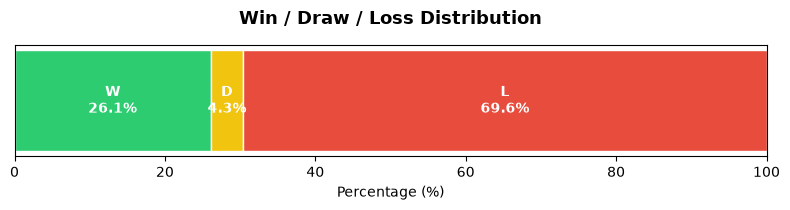

In [10]:

# Colors for W/D/L
colors = {"W": "#2ecc71", "D": "#f1c40f", "L": "#e74c3c"}

fig, ax = plt.subplots(figsize=(8, 2.2))

left = 0
for result in ["W", "D", "L"]:
    pct = wdl_summary.loc[result, "Rate (%)"]
    cnt = wdl_summary.loc[result, "Count"]
    ax.barh(
        y=0,
        width=pct,
        left=left,
        color=colors[result],
        edgecolor="white",
        height=0.6,
        label=f"{result} ({cnt})"
    )
    # Annotate inside the segment if it's wide enough
    if pct > 4:  # avoid clutter on tiny slices
        ax.text(
            left + pct / 2, 0,
            f"{result}\n{pct:.1f}%",
            ha="center", va="center",
            fontsize=10, fontweight="bold",
            color="white"
        )
    left += pct

# Clean up axes
ax.set_xlim(0, 100)
ax.set_yticks([])
ax.set_xlabel("Percentage (%)")
ax.set_title("Win / Draw / Loss Distribution", fontsize=13, fontweight="bold", pad=15)

# Legend below the chart
"""
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.35),
    ncol=3,
    frameon=False
)"""

plt.tight_layout()
plt.show()